imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 12

configuração

In [2]:
file_path = "../data/processed/cnn_X.npy"
fs = 200  # Hz

carregar dados

In [3]:
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Arquivo não encontrado: {file_path}")

ecg_data = np.load(file_path)

print("Shape original:", ecg_data.shape)
print("Dtype:", ecg_data.dtype)

Shape original: (23005, 3600)
Dtype: float32


selecionar um sinal

In [4]:
if ecg_data.ndim == 1:
    ecg_signal = ecg_data
elif ecg_data.ndim == 2:
    ecg_signal = ecg_data[0]
elif ecg_data.ndim == 3:
    ecg_signal = ecg_data[0, :, 0]
else:
    raise ValueError(f"Formato não suportado: {ecg_data.shape}")

ecg_signal = np.asarray(ecg_signal).astype(float)

print("Shape do sinal selecionado:", ecg_signal.shape)
print("Primeiros valores:", ecg_signal[:10])

Shape do sinal selecionado: (3600,)
Primeiros valores: [1.02760565 1.02760565 1.02760565 1.02760565 1.02760565 1.02760565
 1.02760565 1.02760565 1.17447174 1.08635211]


vetor de tempo

In [5]:
t = np.arange(len(ecg_signal)) / fs
duration = len(ecg_signal) / fs

print(f"Amostras: {len(ecg_signal)}")
print(f"Duração: {duration:.2f} s")

Amostras: 3600
Duração: 18.00 s


filtro passa-banda

In [6]:
def bandpass_filter(signal, lowcut=5, highcut=15, fs=200, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)

ecg_band = bandpass_filter(ecg_signal, lowcut=5, highcut=15, fs=fs, order=2)

derivada, quadrado e integração

In [7]:
ecg_derivative = np.gradient(ecg_band)
ecg_squared = ecg_derivative ** 2

window_ms = 150
window_samples = int((window_ms / 1000) * fs)
if window_samples < 1:
    window_samples = 1

kernel = np.ones(window_samples) / window_samples
ecg_integrated = np.convolve(ecg_squared, kernel, mode="same")

threshold e detecção dos picos

In [8]:
threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)
min_distance_samples = int(0.3 * fs)

peaks, properties = find_peaks(
    ecg_integrated,
    height=threshold,
    distance=min_distance_samples
)

print(f"Threshold: {threshold:.4f}")
print(f"Picos detectados: {len(peaks)}")

Threshold: 0.0914
Picos detectados: 13


sinal integrado com picos

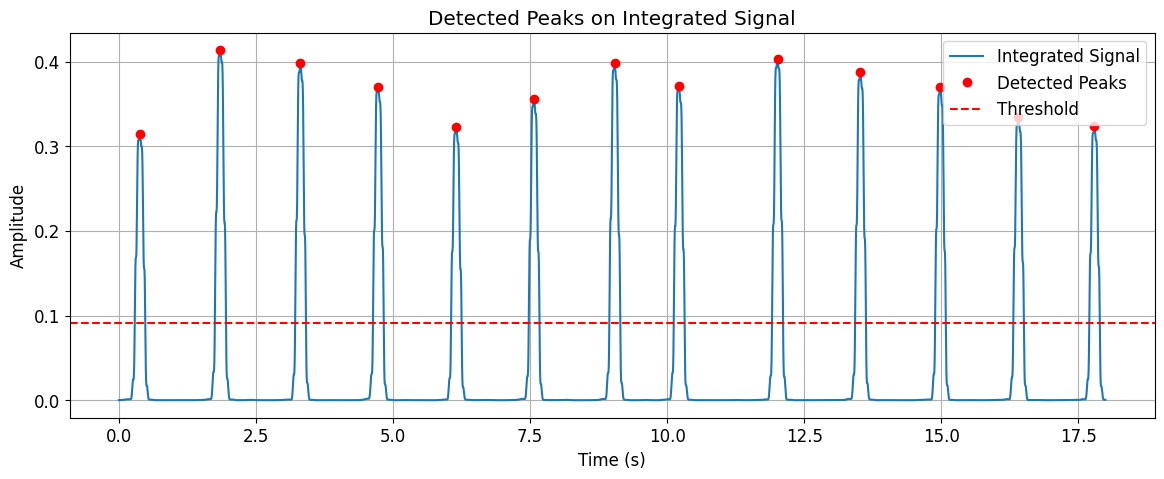

In [9]:
plt.figure()
plt.plot(t, ecg_integrated, label="Integrated Signal")
plt.plot(t[peaks], ecg_integrated[peaks], "ro", label="Detected Peaks")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Detected Peaks on Integrated Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

ECG bruto com R-peaks

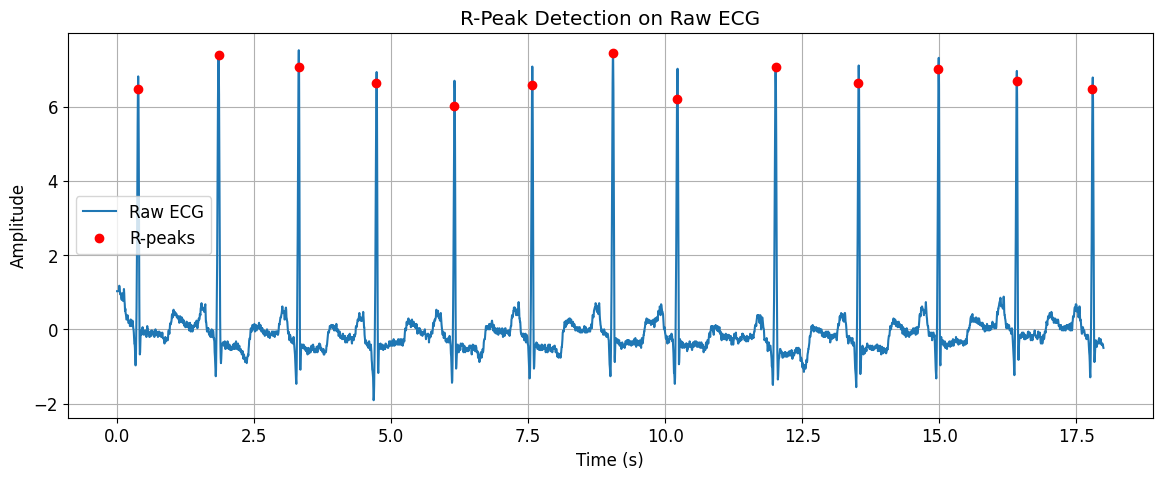

In [10]:
plt.figure()
plt.plot(t, ecg_signal, label="Raw ECG")
plt.plot(t[peaks], ecg_signal[peaks], "ro", label="R-peaks")
plt.title("R-Peak Detection on Raw ECG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

zoom curto do sinal com picos

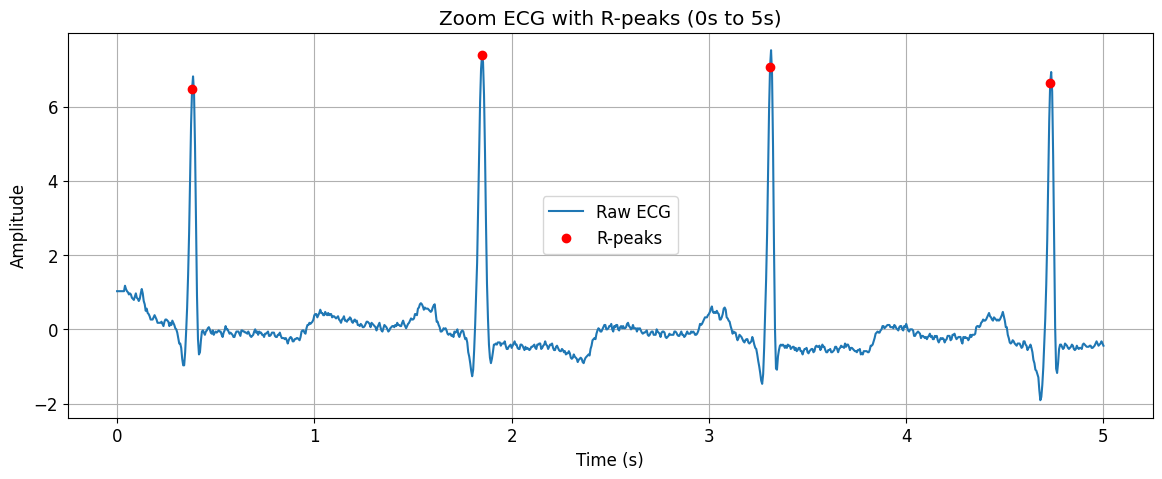

In [11]:
zoom_start_s = 0
zoom_end_s = 5

mask = (t >= zoom_start_s) & (t <= zoom_end_s)
peak_mask = (t[peaks] >= zoom_start_s) & (t[peaks] <= zoom_end_s)

plt.figure()
plt.plot(t[mask], ecg_signal[mask], label="Raw ECG")
plt.plot(t[peaks][peak_mask], ecg_signal[peaks][peak_mask], "ro", label="R-peaks")
plt.title(f"Zoom ECG with R-peaks ({zoom_start_s}s to {zoom_end_s}s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

múltiplos zooms automáticos

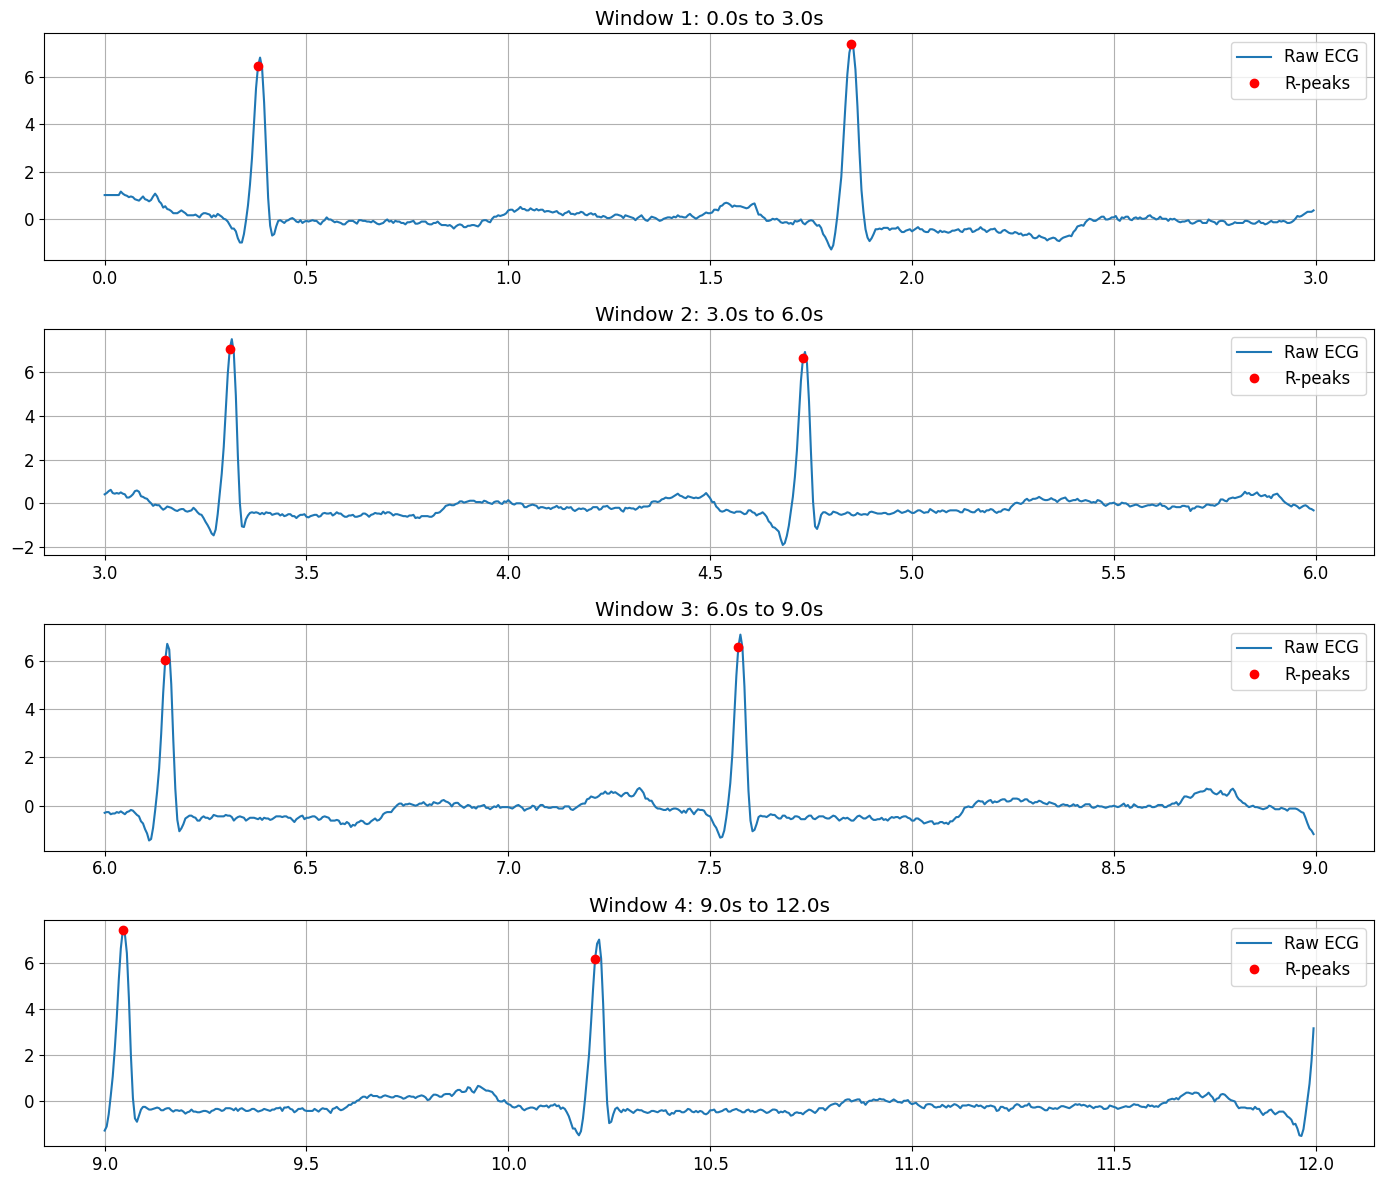

In [12]:
window_sec = 3
num_windows = min(4, int(duration // window_sec))

fig, axes = plt.subplots(num_windows, 1, figsize=(14, 3 * num_windows), sharex=False)

if num_windows == 1:
    axes = [axes]

for i in range(num_windows):
    start = i * window_sec
    end = start + window_sec

    mask = (t >= start) & (t < end)
    peak_mask = (t[peaks] >= start) & (t[peaks] < end)

    axes[i].plot(t[mask], ecg_signal[mask], label="Raw ECG")
    axes[i].plot(t[peaks][peak_mask], ecg_signal[peaks][peak_mask], "ro", label="R-peaks")
    axes[i].set_title(f"Window {i+1}: {start:.1f}s to {end:.1f}s")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

RR intervals

In [13]:
if len(peaks) > 1:
    rr_intervals_s = np.diff(t[peaks])
    rr_intervals_ms = rr_intervals_s * 1000

    print("Primeiros RR intervals (ms):")
    print(rr_intervals_ms[:10])
else:
    rr_intervals_s = np.array([])
    rr_intervals_ms = np.array([])
    print("Picos insuficientes para RR interval.")

Primeiros RR intervals (ms):
[1470. 1460. 1420. 1420. 1420. 1475. 1170. 1800. 1510. 1460.]


histograma dos RR intervals

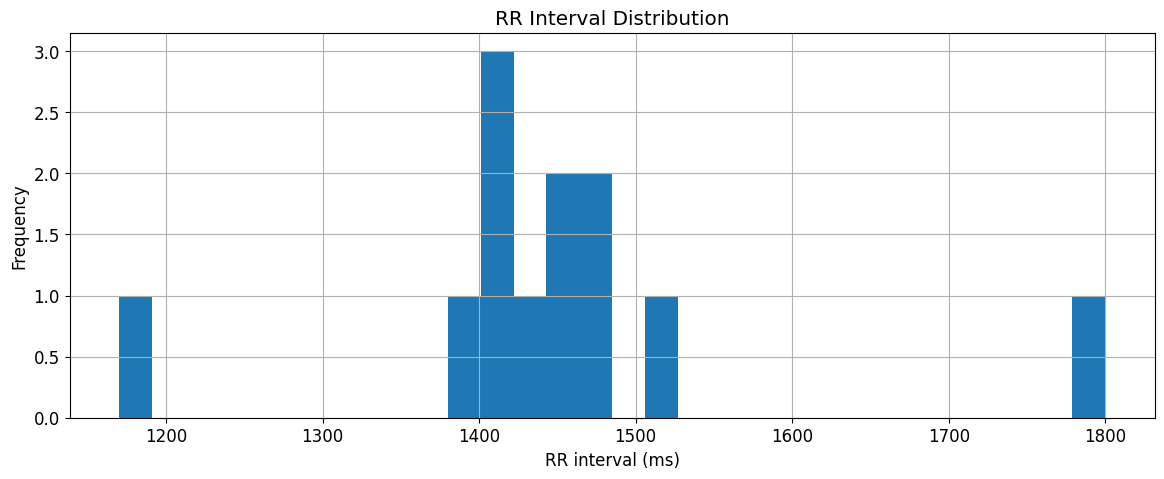

In [14]:
if len(rr_intervals_ms) > 0:
    plt.figure()
    plt.hist(rr_intervals_ms, bins=30)
    plt.title("RR Interval Distribution")
    plt.xlabel("RR interval (ms)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

BPM instantâneo

In [15]:
if len(rr_intervals_s) > 0:
    bpm_inst = 60 / rr_intervals_s
    bpm_mean = np.mean(bpm_inst)

    print("Primeiros BPM instantâneos:")
    print(bpm_inst[:10])
    print(f"BPM médio: {bpm_mean:.2f}")
else:
    bpm_inst = np.array([])
    bpm_mean = 0
    print("RR insuficiente para cálculo de BPM.")

Primeiros BPM instantâneos:
[40.81632653 41.09589041 42.25352113 42.25352113 42.25352113 40.6779661
 51.28205128 33.33333333 39.73509934 41.09589041]
BPM médio: 41.69


gráfico do BPM

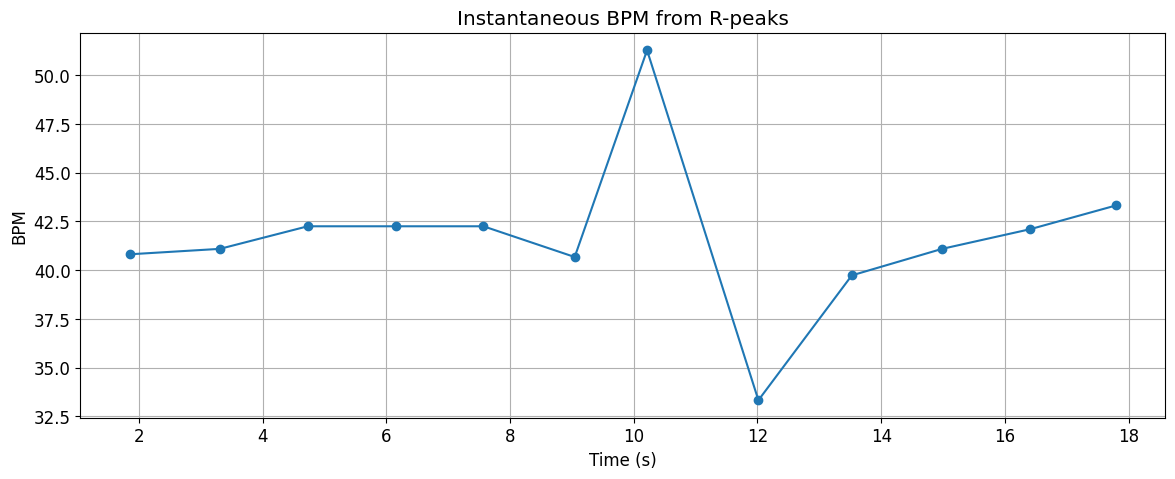

In [16]:
if len(bpm_inst) > 0:
    plt.figure()
    plt.plot(t[peaks][1:], bpm_inst, marker="o")
    plt.title("Instantaneous BPM from R-peaks")
    plt.xlabel("Time (s)")
    plt.ylabel("BPM")
    plt.grid(True)
    plt.show()

tabela-resumo

In [17]:
summary = {
    "Total samples": len(ecg_signal),
    "Duration (s)": duration,
    "Detected peaks": len(peaks),
    "Mean BPM": bpm_mean if len(bpm_inst) > 0 else None,
    "Mean RR (ms)": np.mean(rr_intervals_ms) if len(rr_intervals_ms) > 0 else None,
    "Std RR (ms)": np.std(rr_intervals_ms) if len(rr_intervals_ms) > 0 else None,
}

for k, v in summary.items():
    print(f"{k}: {v}")

Total samples: 3600
Duration (s): 18.0
Detected peaks: 13
Mean BPM: 41.68530696537696
Mean RR (ms): 1451.25
Std RR (ms): 133.3092426153066


validação visual de segmentos aleatórios

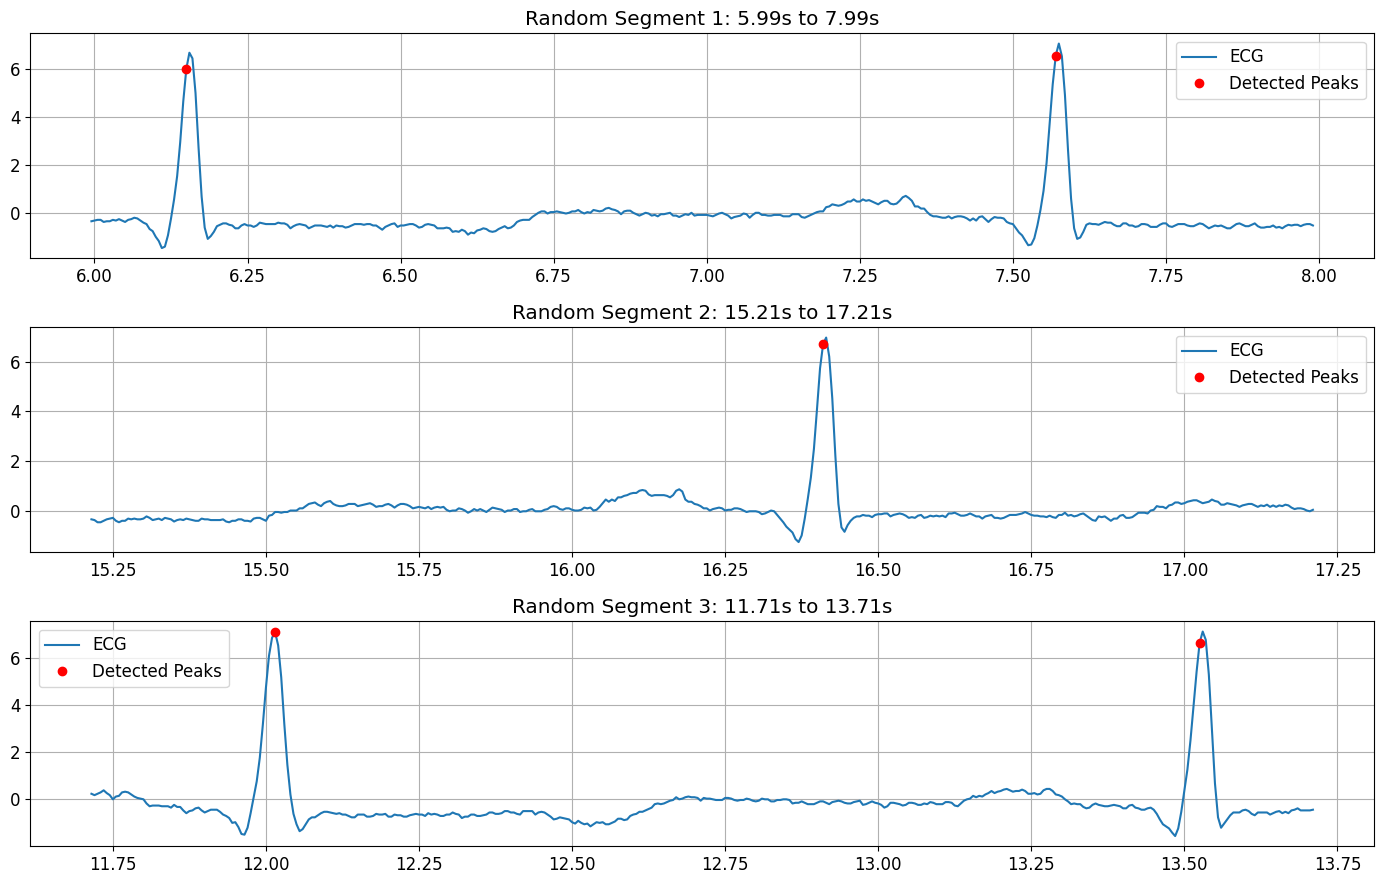

In [18]:
np.random.seed(42)

segment_duration = 2  # segundos
num_segments = 3

fig, axes = plt.subplots(num_segments, 1, figsize=(14, 3 * num_segments))

if num_segments == 1:
    axes = [axes]

for i in range(num_segments):
    start = np.random.uniform(0, max(0.1, duration - segment_duration))
    end = start + segment_duration

    mask = (t >= start) & (t <= end)
    peak_mask = (t[peaks] >= start) & (t[peaks] <= end)

    axes[i].plot(t[mask], ecg_signal[mask], label="ECG")
    axes[i].plot(t[peaks][peak_mask], ecg_signal[peaks][peak_mask], "ro", label="Detected Peaks")
    axes[i].set_title(f"Random Segment {i+1}: {start:.2f}s to {end:.2f}s")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

observações automáticas

In [19]:
if len(rr_intervals_ms) > 0:
    print("Observações:")
    print(f"- RR médio: {np.mean(rr_intervals_ms):.2f} ms")
    print(f"- RR desvio padrão: {np.std(rr_intervals_ms):.2f} ms")
    print(f"- BPM médio: {bpm_mean:.2f}")

    if bpm_mean < 60:
        print("- Possível tendência de bradicardia.")
    elif bpm_mean > 100:
        print("- Possível tendência de taquicardia.")
    else:
        print("- BPM médio dentro da faixa usual.")
else:
    print("Sem RR intervals suficientes para observações.")

Observações:
- RR médio: 1451.25 ms
- RR desvio padrão: 133.31 ms
- BPM médio: 41.69
- Possível tendência de bradicardia.


conclusão

In [20]:
print("Notebook 03 - R-Peak Detection completed successfully.")
print("This notebook provides:")
print("- R-peak visualization")
print("- RR interval analysis")
print("- Instant BPM calculation")
print("- Detection quality inspection using zoomed windows")

Notebook 03 - R-Peak Detection completed successfully.
This notebook provides:
- R-peak visualization
- RR interval analysis
- Instant BPM calculation
- Detection quality inspection using zoomed windows
